In [8]:
# Actividad 02 : Taller de Pandas 
# Se toma el dataset Google Play Store Apps (2026 Edition)

In [9]:
import pandas as pd
print("Pandas se importo correctamente")

Pandas se importo correctamente


In [10]:
Google_Play_Store_Data = pd.read_csv(r"C:\Users\misae\Downloads\google_playstore_2026.csv")
Google_Play_Store_Data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,In-App Purchases,Ad Supported
0,Strike Plus,FAMILY,4.6,12460594,Varies with device,"500,000,000+",Free,0.00,Teen,Family,"January 15, 2026",Varies with device,8.0 and up,Yes,Yes
1,Tracker AI,EDUCATION,3.4,11487705,Varies with device,"500,000,000+",Free,0.00,Everyone,Education,"October 22, 2025",Varies with device,11.0 and up,Yes,Yes
2,Scanner,FAMILY,3.5,10503932,Varies with device,"500,000,000+",Paid,0.99,Everyone,Family,"November 08, 2024",Varies with device,10.0 and up,No,No
3,Connect 3D,ART_AND_DESIGN,4.7,4818860,221.6M,"100,000,000+",Free,0.00,Everyone,Art And Design,"October 07, 2025",6.8.21,10.0 and up,No,Yes
4,VPN,PRODUCTIVITY,3.5,3562800,122.9M,"100,000,000+",Free,0.00,Everyone,Productivity,"June 29, 2026",5.5.11,12.0 and up,Yes,Yes


In [11]:
#Limpieza de datos

In [12]:
# Diagnostico del tipo de datos y nulos
Google_Play_Store_Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               11500 non-null  str    
 1   Category          11500 non-null  str    
 2   Rating            6123 non-null   float64
 3   Reviews           11500 non-null  int64  
 4   Size              11500 non-null  str    
 5   Installs          11500 non-null  str    
 6   Type              11500 non-null  str    
 7   Price             11500 non-null  float64
 8   Content Rating    11500 non-null  str    
 9   Genres            11500 non-null  str    
 10  Last Updated      11500 non-null  str    
 11  Current Ver       11500 non-null  str    
 12  Android Ver       11500 non-null  str    
 13  In-App Purchases  11500 non-null  str    
 14  Ad Supported      11500 non-null  str    
dtypes: float64(2), int64(1), str(12)
memory usage: 1.3 MB


In [13]:
# Se validan los datos nulos de la columna rating, se eliminan los registros sin calificación para responder a la primera pregunta

df_rating = Google_Play_Store_Data.dropna(subset=['Rating'])

In [14]:
df_rating.info()

<class 'pandas.DataFrame'>
Index: 6123 entries, 0 to 9717
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               6123 non-null   str    
 1   Category          6123 non-null   str    
 2   Rating            6123 non-null   float64
 3   Reviews           6123 non-null   int64  
 4   Size              6123 non-null   str    
 5   Installs          6123 non-null   str    
 6   Type              6123 non-null   str    
 7   Price             6123 non-null   float64
 8   Content Rating    6123 non-null   str    
 9   Genres            6123 non-null   str    
 10  Last Updated      6123 non-null   str    
 11  Current Ver       6123 non-null   str    
 12  Android Ver       6123 non-null   str    
 13  In-App Purchases  6123 non-null   str    
 14  Ad Supported      6123 non-null   str    
dtypes: float64(2), int64(1), str(12)
memory usage: 765.4 KB


In [15]:
df_rating['Rating'].describe()

count    6123.000000
mean        4.057211
std         0.586312
min         1.900000
25%         3.600000
50%         4.100000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [16]:
# Para columna Last Updated se convierte a fecha

Google_Play_Store_Data['Last Updated'] = pd.to_datetime(df_rating['Last Updated'])

In [17]:
# Se cambia la columna Installs a tipo númerico
Google_Play_Store_Data['Installs'] = (
    Google_Play_Store_Data['Installs']
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    .astype(int)
)

In [18]:
# Se validan duplicados 
Google_Play_Store_Data.duplicated().sum()


np.int64(0)

In [19]:
# Preguntas de Análisis
# Pregunta 1
# ¿Cuáles son las 10 categorías de aplicaciones que tienen la mejor calificación promedio?

In [20]:
# Selecciono las columnas necesarias
category_rating = df_rating[['Category', 'Rating']]

# Se calcula el promedio de calificación por categoría
promedio_category = (category_rating.groupby('Category')['Rating'].mean().sort_values(ascending=False))

print(promedio_category)

Category
ARTIFICIAL_INTELLIGENCE    4.285748
GAME                       4.273987
EDUCATION                  4.235088
WEB3_AND_CRYPTO            4.129412
WEATHER                    4.106154
SHOPPING                   4.097015
AUTO_AND_VEHICLES          4.090476
PARENTING                  4.078571
NEWS_AND_MAGAZINES         4.052000
VIDEO_PLAYERS              4.046377
MAPS_AND_NAVIGATION        4.033784
MEDICAL                    4.025000
ART_AND_DESIGN             4.007843
FAMILY                     4.005225
VIRTUAL_REALITY            4.003279
LIBRARIES_AND_DEMO         3.994643
PRODUCTIVITY               3.989773
TOOLS                      3.989655
ENTERTAINMENT              3.974603
BEAUTY                     3.973684
FINANCE                    3.967003
HOUSE_AND_HOME             3.965714
TRAVEL_AND_LOCAL           3.964062
DATING                     3.957778
LIFESTYLE                  3.954545
SPORTS                     3.951429
PHOTOGRAPHY                3.946479
PERSONALIZATION    

In [21]:
# Se calcula el promedio con dos decimales
promedio_category.round(2).head(10)

Category
ARTIFICIAL_INTELLIGENCE    4.29
GAME                       4.27
EDUCATION                  4.24
WEB3_AND_CRYPTO            4.13
WEATHER                    4.11
SHOPPING                   4.10
AUTO_AND_VEHICLES          4.09
PARENTING                  4.08
NEWS_AND_MAGAZINES         4.05
VIDEO_PLAYERS              4.05
Name: Rating, dtype: float64

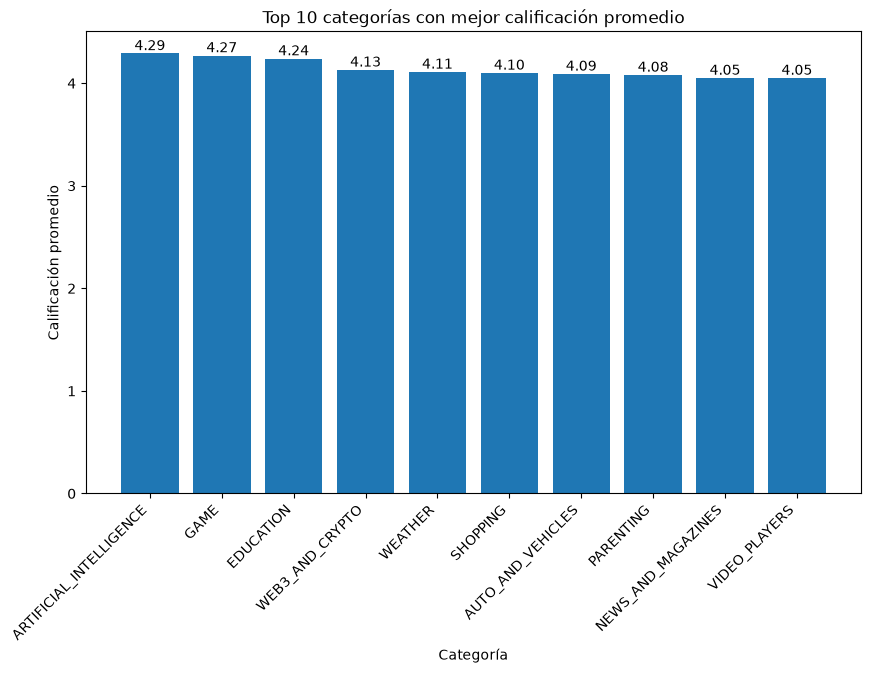

In [22]:
# Validamos por medio de una grafica
import matplotlib.pyplot as plt

top10 = promedio_category.round(2).head(10)

plt.figure(figsize=(10,6))
barras = plt.bar(top10.index, top10.values)

plt.title('Top 10 categorías con mejor calificación promedio')
plt.xlabel('Categoría')
plt.ylabel('Calificación promedio')
plt.xticks(rotation=45, ha='right')

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.2f}',
        ha='center',
        va='bottom'
    )

In [ ]:
# Conslusión

# Dentro del Dataset se evidencia que la categoria de Inteligencia Artificial, juego y educación presenta las mejores calificaciones promedio, por lo que los usuarios presentan una preferencia por el entretenimiento y la tecnología.

In [ ]:
# Pregunta 2
#2. ¿Qué categorias tienen el mayor número de instalaciones?

In [25]:
# Seleccionamos las columnas necesarias
category_installs = Google_Play_Store_Data[['Category', 'Installs']]

# Suma de instalaciones
suma_installs = (category_installs.groupby('Category')['Installs'].sum().sort_values(ascending=False))

print(suma_installs)

Category
FAMILY                     1343762060
EDUCATION                   532199960
PRODUCTIVITY                318156570
TOOLS                       303649410
GAME                        292635680
ARTIFICIAL_INTELLIGENCE     262755700
ART_AND_DESIGN              201809220
SOCIAL                      130262330
MEDICAL                     112387060
WEATHER                     107277640
PHOTOGRAPHY                  77160110
FINANCE                      38548620
FOOD_AND_DRINK               23355760
MAPS_AND_NAVIGATION          23332090
VIDEO_PLAYERS                21718350
LIBRARIES_AND_DEMO           17664210
HOUSE_AND_HOME               14903510
PERSONALIZATION              13385750
BUSINESS                     13166280
PARENTING                    12747300
EVENTS                       12483000
WEB3_AND_CRYPTO              10551100
LIFESTYLE                    10167830
BOOKS_AND_REFERENCE           7316550
COMMUNICATION                 6669490
TRAVEL_AND_LOCAL              5940710
SHO

In [ ]:
# Realizamos la suma de las instalaciones por categoría
suma_installs.head(10)

Category
FAMILY                     1343762060
EDUCATION                   532199960
PRODUCTIVITY                318156570
TOOLS                       303649410
GAME                        292635680
ARTIFICIAL_INTELLIGENCE     262755700
ART_AND_DESIGN              201809220
SOCIAL                      130262330
MEDICAL                     112387060
WEATHER                     107277640
Name: Installs, dtype: int64

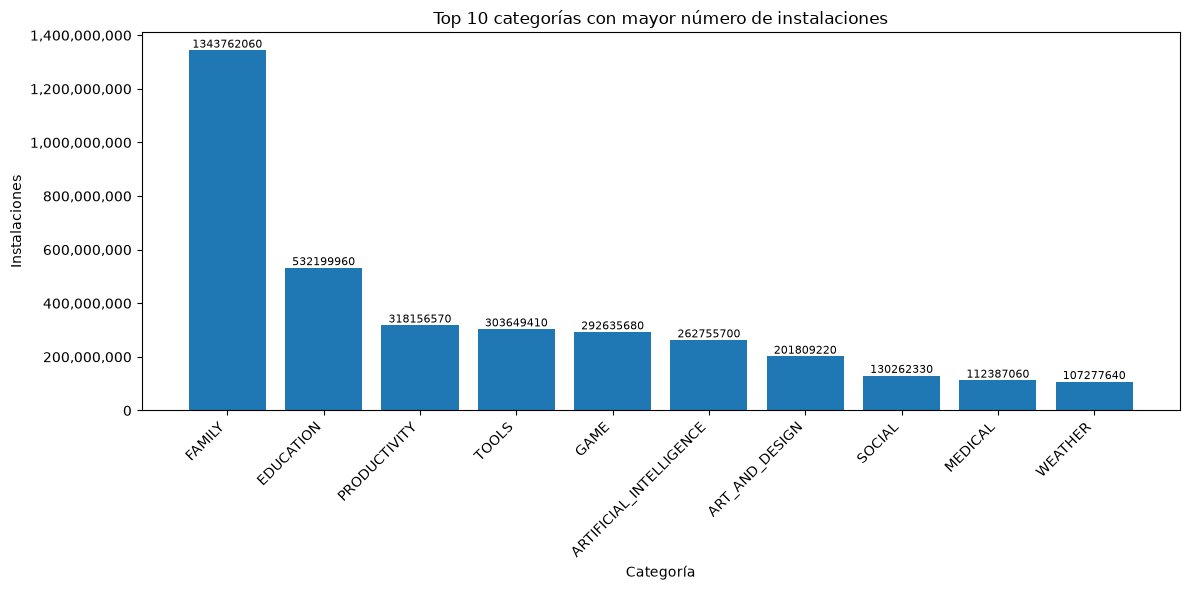

In [27]:
top10 = suma_installs.head(10)

from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(12,6))
barras = plt.bar(top10.index, top10.values)

plt.title('Top 10 categorías con mayor número de instalaciones')
plt.xlabel('Categoría')
plt.ylabel('Instalaciones')
plt.xticks(rotation=45, ha='right')

# Separador de miles
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.0f}',
        ha='center',
        va='bottom', fontsize=8,
        rotation=0
    )

plt.tight_layout()
plt.show()

In [ ]:
# Conclusiones
# La categoría de Familia cuenta con el mayor número de instalaciones, así como educación y productividad, indicando una amplia aceptación y presencía en las aplicaciones favoritas de los usuarios de Google Play Store, seguidos por aplicaciones de entretenimiento.

In [29]:
# Pregunta 3
# 3. ¿Las aplicaciones gratuitas tiene mas instalacines que las aplicaciones de pago?

In [30]:
df_aplicaciones = Google_Play_Store_Data[['Type', 'Installs']]

In [31]:
# Filtramos aplicaciones gratuitas y de pago
df_free = Google_Play_Store_Data[Google_Play_Store_Data['Type'] == 'Free']
df_paid = Google_Play_Store_Data[Google_Play_Store_Data['Type'] == 'Paid']

print("Aplicaciones gratuitas:", len(df_free))
print("Aplicaciones de pago:", len(df_paid))

Aplicaciones gratuitas: 11027
Aplicaciones de pago: 473


In [32]:
# Validamos la suma de las aplicaciones gratuitas y de pago
instalaciones_tipo = (
    df_aplicaciones
    .groupby('Type')['Installs']
    .sum()
    .sort_values(ascending=False)
)

instalaciones_tipo

Type
Free    3411905540
Paid     529985910
Name: Installs, dtype: int64

In [33]:
# Sacamos el porcentaje de aplicaciones gratuitas y aplicaciones de pago
porcentaje_tipo = (
    Google_Play_Store_Data['Type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(porcentaje_tipo)

Type
Free    95.89
Paid     4.11
Name: proportion, dtype: float64


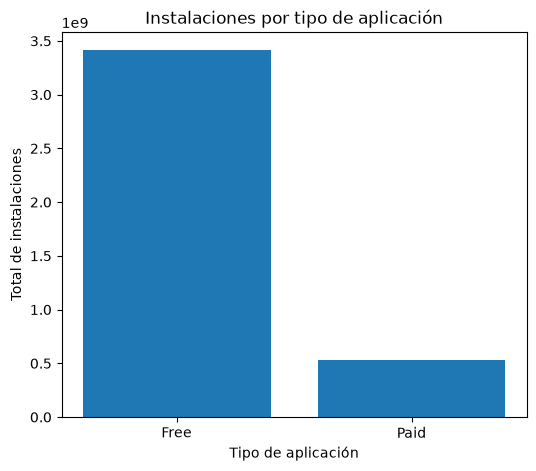

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.bar(instalaciones_tipo.index, instalaciones_tipo.values)

plt.title('Instalaciones por tipo de aplicación')
plt.xlabel('Tipo de aplicación')
plt.ylabel('Total de instalaciones')

plt.show()

In [ ]:
# Conclusión
# Se evidencia una tendencia en donde las aplicaciones gratuitas tienen un mayor número de instalaciones, teniendo en cuenta que la mayoria de aplicaciones son gratuidas con un aproximado del 95% a diferencia del 4,11% de aplicaciones de pago, podría responder a la diferencia de instalaciones de los tipos de aplicaciones.